In [1]:
%cd ../../

/home/hoanghu/projects/fw-models


In [2]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, AdaBoostRegressor
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and resources

In [4]:
path = "data/processed/phase_4/dim_pieces_per_dish.xlsx"
pos = pl.read_excel(path)
pos.head()

date,restaurant,meal_type,pcs,meal_id
date,str,str,i64,i64
2023-01-02,"""che""","""fish""",78,9500055
2023-01-02,"""che""","""vegan""",84,6128
2023-01-02,"""che""","""meat""",165,9500160
2023-01-03,"""che""","""vegetarian""",29,1270
2023-01-03,"""che""","""fish""",105,6156


In [5]:
path = "data/inter/meal_names_embds.parquet"
meal_names = pl.read_parquet(path).drop('__index_level_0__')
meal_names.head()

meal_id,meal,embedding
i64,str,list[f64]
7010,"""Aurajuusto-pinaattilasagnette""","[0.011678, -0.039025, … 0.035513]"
7010,"""Aurajuusto-pinaattilasagnettea""","[0.01346, -0.047018, … 0.038673]"
1751,"""BBQ-broilerikastiketta""","[0.050395, 0.037269, … 0.025638]"
1751,"""BBQ-Broilerikastiketta""","[0.065942, 0.037054, … 0.022381]"
200006,"""Bar Myöhä Bbq-seitanbowl""","[0.020469, 0.026279, … 0.028041]"


## Pre-process data

In [6]:
# Filter out too low POS values
THETA = 5
pos = pos.filter(pl.col('pcs') >= THETA)


pos.head()

date,restaurant,meal_type,pcs,meal_id
date,str,str,i64,i64
2023-01-02,"""che""","""fish""",78,9500055
2023-01-02,"""che""","""vegan""",84,6128
2023-01-02,"""che""","""meat""",165,9500160
2023-01-03,"""che""","""vegetarian""",29,1270
2023-01-03,"""che""","""fish""",105,6156


In [7]:
pos = (
    pos
    .join(meal_names, on='meal_id', how='left')
    .drop('meal', 'meal_id')
    # .filter(pl.col('embedding').is_null())
)

pos.head()

date,restaurant,meal_type,pcs,embedding
date,str,str,i64,list[f64]
2023-01-02,"""che""","""fish""",78,"[0.014626, 0.004826, … 0.00013]"
2023-01-02,"""che""","""vegan""",84,"[0.057244, -0.012788, … 0.021495]"
2023-01-02,"""che""","""vegan""",84,"[0.028636, -0.135223, … 0.025385]"
2023-01-02,"""che""","""meat""",165,"[0.053035, 0.038544, … 0.026033]"
2023-01-03,"""che""","""vegetarian""",29,"[-0.020129, -0.041059, … 0.043573]"


# Encode

In [8]:
# Encode restaurant
enc_restaurant = OrdinalEncoder()
enc_restaurant.fit(pos.select('restaurant'))
pos = pos.with_columns(
    pl.Series('restaurant_enc', values=enc_restaurant.transform(pos.select('restaurant'))).arr.first().cast(pl.Int32),
)



# Encode meal type
enc_meal_type = OrdinalEncoder()
enc_meal_type.fit(pos.select('meal_type'))
pos = pos.with_columns(
    pl.Series('meal_type_enc', values=enc_meal_type.transform(pos.select('meal_type'))).arr.first().cast(pl.Int32),
)



# Encode datetime
pos = (
    pos
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)



# Convert embedding vector to column
pos = pos.with_columns(pl.col("embedding").list.to_struct()).unnest("embedding")



pos.head()

date,restaurant,meal_type,pcs,field_0,field_1,field_2,field_3,field_4,field_5,field_6,field_7,field_8,field_9,field_10,field_11,field_12,field_13,field_14,field_15,field_16,field_17,field_18,field_19,field_20,field_21,field_22,field_23,field_24,field_25,field_26,field_27,field_28,field_29,field_30,field_31,field_32,…,field_995,field_996,field_997,field_998,field_999,field_1000,field_1001,field_1002,field_1003,field_1004,field_1005,field_1006,field_1007,field_1008,field_1009,field_1010,field_1011,field_1012,field_1013,field_1014,field_1015,field_1016,field_1017,field_1018,field_1019,field_1020,field_1021,field_1022,field_1023,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos
date,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,f64,f64,f64,f64,f64,f64
2023-01-02,"""che""","""fish""",78,0.014626,0.004826,0.112185,-0.006399,0.131224,0.018513,-0.076155,-0.019904,-0.107217,0.17537,0.083286,0.045625,-0.139644,-0.024016,0.004403,-0.096446,-0.099442,0.03328,-0.00195,-0.094967,0.004988,0.036008,-0.044203,-0.03035,-0.075966,-0.106496,0.066769,0.052926,0.004188,0.021864,-0.032967,0.090036,-0.058349,…,0.006324,-0.009071,0.013973,-0.007661,0.005919,0.063754,0.024206,0.01399,0.029687,0.002414,-0.021234,0.05668,-0.042193,0.0225,0.004023,-0.013743,0.057012,0.025884,-0.016142,-0.022688,0.038526,-0.010516,0.008152,0.022474,-0.024138,-0.035935,0.016567,-0.025728,0.00013,0,1,0.781831,0.62349,0.394356,0.918958,0.5,0.866025
2023-01-02,"""che""","""vegan""",84,0.057244,-0.012788,0.087151,-0.073389,0.058711,0.056288,-0.030739,0.065212,-0.058052,0.146051,-0.020744,0.081151,-0.202178,-0.082483,-0.053027,-0.069527,-0.116049,-0.016646,0.010462,0.0062,-0.051809,0.069151,0.056632,-0.061953,-0.043031,-0.017447,0.0833,0.005041,0.001222,0.043821,-0.054527,-0.038954,-0.044235,…,-0.009637,0.044363,-0.003114,-0.00012,0.039096,0.030257,-0.000248,0.017365,0.058993,-0.008119,-0.025844,0.011412,-0.031071,-0.010126,0.042109,0.0007,0.030766,0.017621,0.013208,0.003622,0.047282,0.009107,-0.022871,0.001641,-0.022047,-0.048136,0.031585,-0.035347,0.021495,0,3,0.781831,0.62349,0.394356,0.918958,0.5,0.866025
2023-01-02,"""che""","""vegan""",84,0.028636,-0.135223,0.052546,-0.051806,0.091727,0.104154,-0.021548,0.06702,-0.086598,0.075551,0.064381,0.137689,-0.127628,-0.046948,0.018316,-0.039292,-0.091973,-0.137195,0.0765,0.038269,0.018826,0.063691,0.045863,-0.051683,-0.043324,0.041467,0.00155,0.003005,-0.008078,0.05622,-0.068006,-0.018335,-0.039329,…,0.009006,0.037034,-0.011275,-0.02618,0.041425,0.034225,0.017576,0.007724,0.012927,-0.03007,-0.01088,0.005674,-0.035273,-0.009488,0.023523,0.020711,0.01144,0.015029,0.001017,0.015218,0.022445,0.018604,0.008174,0.006476,-0.014006,-0.010991,0.03281,-0.014798,0.025385,0,3,0.781831,0.62349,0.394356,0.918958,0.5,0.866025
2023-01-02,"""che""","""meat""",165,0.053035,0.038544,0.076745,0.020636,0.066814,-0.003377,0.005136,0.077568,-0.07414,0.199216,-0.066531,0.032768,-0.150783,-0.004914,-0.117329,0.023951,-0.103036,0.050284,0.000509,0.00908,-0.117466,0.052323,0.057688,-0.021444,-0.005129,0.017286,0.03743,0.087097,-0.101048,-0.021319,-0.012436,0.011524,-0.114895,…,-0.000082,0.002907,0.035875,0.005547,0.030712,0.032042,0.001174,0.014065,0.02102,0.016122,-0.024242,0.025896,-0.037841,0.040168,0.052855,-0.036642,-0.005725,0.029615,0.01126,-0.008813,0.028936,-0.000546,-0.023582,-0.008291,-0.026033,-0.055785,0.031663,-0.039615,0.026033,0,2,0.781831,0.62349,0.394356,0.918958,0.5,0.866025
2023-01-03,"""che""","""vegetarian""",29,-0.020129,-0.041059,0.02757,0.030865,0.02939,0.017005,0.062531,0.098096,-0.101867,0.20195,-0.082361,0.042924,-0.196597,-0.062552,-0.05949,-0.046919,-0.119872,0.014226,0.086173,-0.060605,-0.032614,0.057868,0.003894,-0.006498,-0.024342,0.050234,0.108801,0.067681,0.018854,-

# Train

In [9]:
CUTOFF_DATE = "2024-10-01"
pos_train = pos.filter(pl.col('date') < pl.lit(CUTOFF_DATE).str.to_datetime()).to_pandas()
pos_val = pos.filter(pl.col('date') >= pl.lit(CUTOFF_DATE).str.to_datetime()).to_pandas()

pos_train.head()

,date,restaurant,meal_type,pcs,field_0,field_1,field_2,field_3,field_4,field_5,...,field_1022,field_1023,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos
0,2023-01-02,che,fish,78,0.014626,0.004826,0.112185,-0.006399,0.131224,0.018513,...,-0.025728,0.000130,0,1,0.781831,0.623490,0.394356,0.918958,0.5,0.866025
1,2023-01-02,che,vegan,84,0.057244,-0.012788,0.087151,-0.073389,0.058711,0.056288,...,-0.035347,0.021495,0,3,0.781831,0.623490,0.394356,0.918958,0.5,0.866025
2,2023-01-02,che,vegan,84,0.028636,-0.135223,0.052546,-0.051806,0.091727,0.104154,...,-0.014798,0.025385,0,3,0.781831,0.623490,0.394356,0.918958,0.5,0.866025
3,2023-01-02,che,meat,165,0.053035,0.038544,0.076745,0.020636,0.066814,-0.003377,...,-0.039615,0.026033,0,2,0.781831,0.623490,0.394356,0.918958,0.5,0.866025
4,2023-01-03,che,vegetarian,29,-0.020129,-0.041059,0.027570,0.030865,0.029390,0.017005,...,-0.028841,0.043573,0,4,0.974928,-0.222521,0.571268,0.820763,0.5,0.866025


In [ ]:
cols_X = [
    'restaurant_enc', 
    # 'meal_type_enc',
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos',
    *[f"field_{i}" for i in range(1024)]
]
col_y = 'pcs'

Xtrain, ytrain = pos_train[cols_X], pos_train[col_y]
Xval, yval = pos_val[cols_X], pos_val[col_y]

In [13]:
cols_cat = [
    'restaurant_enc', 
    'meal_type_enc',
]
models = {
    'HistGB':   {'model': HistGradientBoostingRegressor(categorical_features=cols_cat), 'is_cat': True},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0), 'is_cat': True},

    'RF':       {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    'Ada':      {'model': AdaBoostRegressor(), 'is_cat': False},
    'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'XGB':      {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: Ada
Start: LBGM
Start: XGB


== Split: val
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: Ada
Start: LBGM
Start: XGB
== Split: train
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: Ada
Start: LBGM
Start: XGB


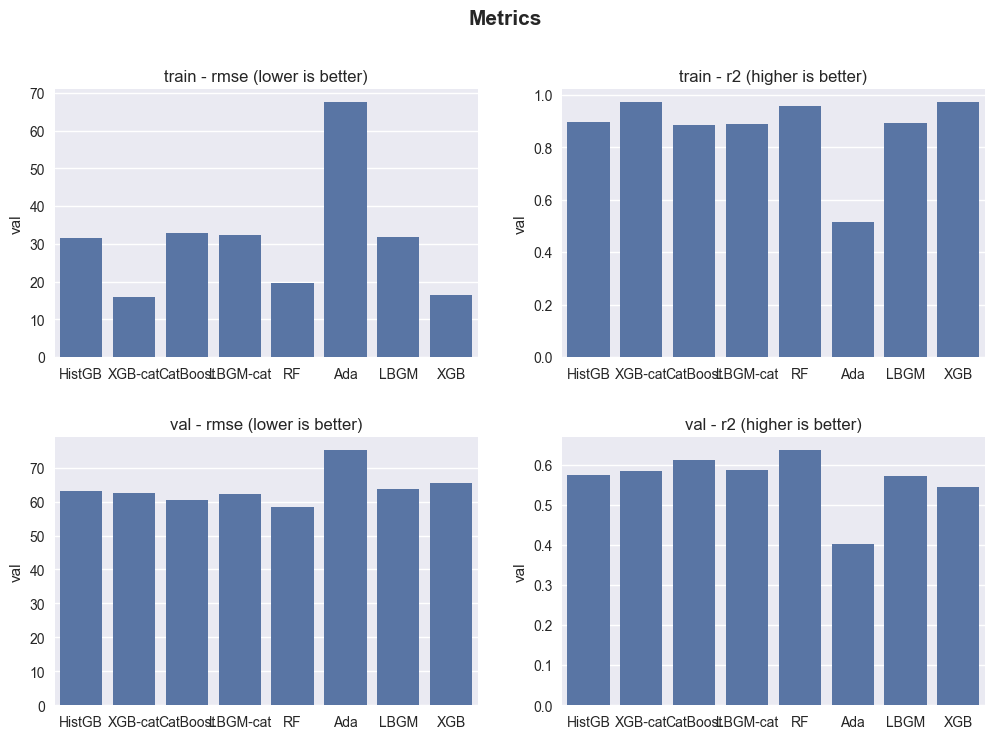

In [14]:
metrics_models = []

def calc_metrics(split: pd.DataFrame, model: dict, verbose: bool = False) -> tuple:
    X = split[cols_X].copy()
    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    split['pcs_pred'] = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    # split = (
    #     split
    #     .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
    #     .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
    #     .reset_index()
    # )
    
    
    rmse = root_mean_squared_error(split['pcs'], split['pcs_pred']).item()
    r2 = r2_score(split['pcs'], split['pcs_pred'])

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"r2  : {r2:.4f}")

    return rmse, r2

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_val, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'val', 'metric': 'r2'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'train', 'metric': 'r2'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'r2'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    description = "lower" if metric == "rmse" else "higher"
    ax.set_title(f"{split} - {metric} ({description} is better)")
    ax.set_xlabel("")


In [18]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['RF']['model'].feature_importances_
})

feat_imp.head()

,name,importance
0,restaurant_enc,0.355546
1,meal_type_enc,0.001369
2,weekday_sin,0.023092
3,weekday_cos,0.023981
4,day_sin,0.048653


<Axes: xlabel='importance', ylabel='name'>

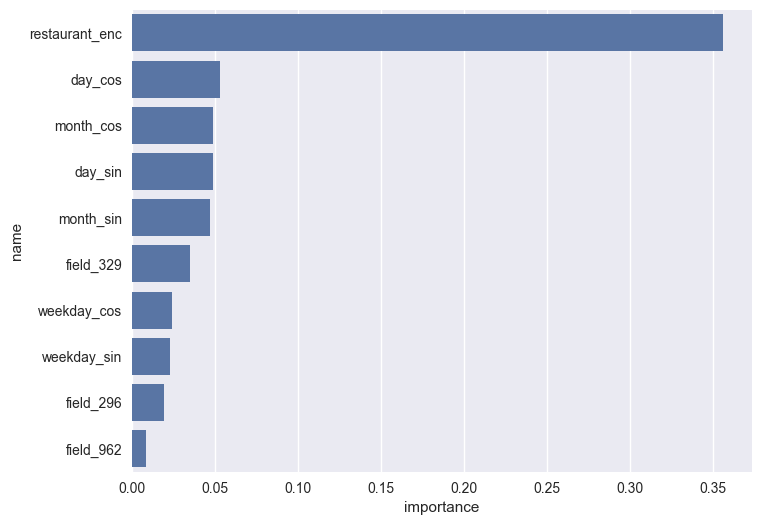

In [19]:
feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:10], y='name', x='importance', ax=ax)